In [1]:
! pip install Pylance matplotlib pandas



[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

file_path = "./docs/서울시 양천구 노래연습장업 인허가 정보.csv"

df = pd.read_csv(file_path)

# df를 통해 '영업상태' 열의 '영업/정상'이면서 지번주소에 '신정'이고 사업장명에 코인이 없는 데이터들이 포함된 것만 출력
act_karaoke_stores_info = df.loc[
                          (df['영업상태명'] == '영업/정상') 
                        & (df['지번주소'].str.contains('신정동', na=False))  
                        # & (df['사업장명'].str.contains('코인', na=False))
                        # 청소년실수 컬럼의 데이터의 값이 없는 것
                        # & (df['청소년실수'].isnull())
                        # & ~(df['전화번호'].isnull())
                        ]
after_COVID19_closed_karaoke_stores_info = df.loc[
                          (df['영업상태명'] == '폐업')
                        & (df['도로명주소'].str.contains(' 중앙로', na=False)) 
                        & (df['사업장명'].str.contains('코인', na=False))
                        # 청소년실수 컬럼의 데이터의 값이 없는 것
                        & (df['폐업일자'] > '2023-07-01')
                        ]

during_COVID19_closed_karaoke_stores_info = df.loc[
                          (df['영업상태명'] == '폐업') 
                        & (df['도로명주소'].str.contains(' 중앙로', na=False)) 
                        & ~(df['사업장명'].str.contains('코인', na=False))
                        # 청소년실수 컬럼의 데이터의 값이 없는 것
                        # (앞의 조건) &
                        & df['폐업일자'].between('2020-01-19', '2023-07-01')
                        ]

before_COVID19_closed_karaoke_stores_info = df.loc[
                          (df['영업상태명'] == '폐업') 
                        & (df['도로명주소'].str.contains(' 중앙로', na=False)) 
                        & ~(df['사업장명'].str.contains('코인', na=False))
                        # 청소년실수 컬럼의 데이터의 값이 없는 것
                        # (앞의 조건) &
                        & (df['폐업일자'] < '2020-01-20')
                        ]



print(f'영업중인 신정네거리 근처 (코인제외)노래방 개수: {len(act_karaoke_stores_info)}')
print(f'코로나 종료시점 이후에 폐업한 신정네거리 근처 (코인제외)노래방 개수: {len(after_COVID19_closed_karaoke_stores_info)}')
print(f'코로나 시점에 폐업한 신정네거리 근처 (코인제외)노래방 개수: {len(during_COVID19_closed_karaoke_stores_info)}')
print(f'코로나 시점에 폐업한 신정네거리 근처 (코인제외)노래방 개수: {len(before_COVID19_closed_karaoke_stores_info)}')
print('======================================')

# act_karaoke_stores_info.loc[:,('사업장명','인허가일자')] 데이터 시각화

영업중인 신정네거리 근처 (코인제외)노래방 개수: 70
코로나 종료시점 이후에 폐업한 신정네거리 근처 (코인제외)노래방 개수: 0
코로나 시점에 폐업한 신정네거리 근처 (코인제외)노래방 개수: 4
코로나 시점에 폐업한 신정네거리 근처 (코인제외)노래방 개수: 25


,사업장명,전화번호,인허가일자
206,둘리노래연습장,NaN,1994-03-21
209,K2노래연습장,NaN,1995-11-26
214,해남노래연습장,26466333,1997-02-17
218,승리노래연습장,NaN,1997-12-27
219,태양노래연습장,NaN,1998-02-16
...,...,...,...
405,뮤직노래연습장,NaN,1993-12-02
406,로또노래연습장,26048206,1993-12-02
407,짱노래연습장,NaN,1993-12-29
410,써니노래연습장,NaN,2002-06-20


In [3]:
# geopandas: 지리정보용 pandas 확장 / contextily: 배경 지도 타일 제공
# (최초 1회만 설치하면 됨)
! pip install geopandas contextily


[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


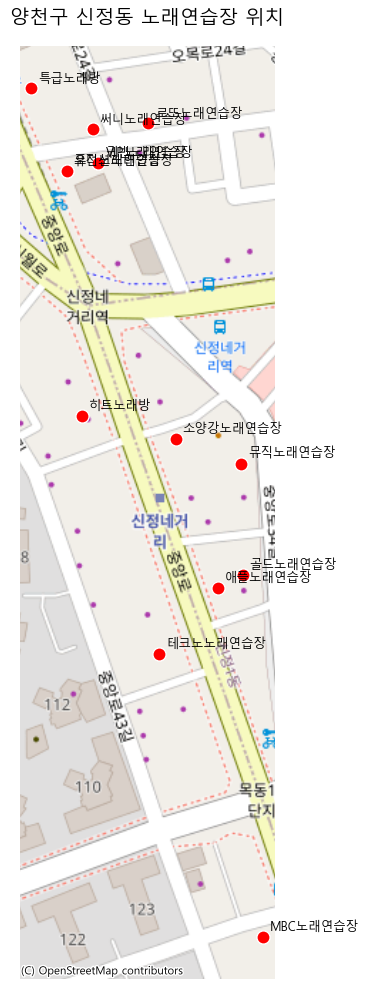

In [ ]:
import geopandas as gpd
import contextily as ctx
import matplotlib.pyplot as plt
import matplotlib



# act_stores_info의 '좌표정보(X)','좌표정보(Y)' 정보로 지도에 표시

# 한글이 깨지지 않도록 폰트 지정 (Windows = 맑은 고딕)
matplotlib.rcParams["font.family"] = "Malgun Gothic"
# 마이너스 기호 깨짐 방지
matplotlib.rcParams["axes.unicode_minus"] = False  

# 1) 좌표 문자열 -> 숫자 변환, 결측 제거
src = act_karaoke_stores_info.copy()
src["좌표정보(X)"] = pd.to_numeric(src["좌표정보(X)"], errors="coerce")
src["좌표정보(Y)"] = pd.to_numeric(src["좌표정보(Y)"], errors="coerce")
src = src.dropna(subset=["좌표정보(X)", "좌표정보(Y)"])

# 2) GeoDataFrame 생성
#    points_from_xy(X, Y) 로 점 geometry를 만들고,
#    원본이 중부원점 TM 좌표이므로 crs="EPSG:5174" 를 반드시 명시한다.
gdf = gpd.GeoDataFrame(
    src,
    geometry=gpd.points_from_xy(src["좌표정보(X)"], src["좌표정보(Y)"]),
    crs="EPSG:5174",
)

# 3) 배경지도(contextily)는 웹 메르카토르(EPSG:3857) 기준이므로 좌표계를 변환
# - 웹 메르카토르(EPSG:3857): 구글 지도, 네이버 지도, OpenStreetMap 등 대부분의 현대 웹 지도 서비스에서 표준
gdf = gdf.to_crs(epsg=3857)

# 4) 점 찍기
fig, ax = plt.subplots(figsize=(10, 10))
gdf.plot(ax=ax, color="red", markersize=90, edgecolor="white", zorder=2)

# 각 점 옆에 매장명 라벨 (geometry.x / geometry.y 로 좌표 접근)
for x, y, name in zip(gdf.geometry.x, gdf.geometry.y, gdf["사업장명"]):
    ax.annotate(name, xy=(x, y), xytext=(5, 5), textcoords="offset points", fontsize=9)

# 5) 실제 지도 타일을 배경으로 추가
ctx.add_basemap(ax, source=ctx.providers.OpenStreetMap.Mapnik) # type: ignore

ax.set_title("양천구 신정동 노래연습장 위치", fontsize=14)
ax.set_axis_off()  # 메르카토르 좌표 눈금은 의미 없으니 숨김
plt.tight_layout()
plt.show()